# The models I choose to work with:

### BERT: DistilBERT:
* BERT Developed by researchers at Google in 2018 for their search engine.
* BERT models are applied to both organic search results and featured snippets.
* DistilBERT developed by Hugging Face. is a small, fast, cheap and light Transformer model trained by distilling BERT base. It has 40% less parameters than bert-base-uncased, runs 60% faster while preserving over 95% of BERT's performances as measured on the GLUE language understanding benchmark.
* Fast and efficient processing makes it ideal for handling short texts, like news titles and descriptions, with minimal latency.
* Open-source.
* Fast, Efficient Real-Time Use.

### BART (seq2seq): 
* Facebook Research's BART combines the capabilities of bi-directional (like BERT) and auto-regressive (like GPT and GPT-2) models.
* Open-source.

### T5: FLAN-T5-Large:
* Developed by Google Research.
* With short texts and no fine-tuning, offers a good balance of efficiency and performance.
* Excellent instruction-tuning performance for QA tasks even without fine-tuning.
* Handles short texts efficiently and should perform well with news titles and descriptions.
* Open-source.
* Good Performance at Lower Cost.

### GPT: GPT-4o-mini:
* One of the best models at the market.
* Deliver excellent out-of-the-box performance without fine-tuning.
* Handles short text snippets very well, providing context-aware answers even with limited information.
* Great at dealing with ambiguous or incomplete information, which is often the case with news titles and descriptions.

### LLaMA: 7B / 3.1:
* Open-source.


### Import the data

In [1]:
from pymongo import MongoClient
import pandas as pd

# MongoDB connection details
mongo_uri = "mongodb://localhost:27017/"
db_name = "task1"
collection_name = "bbc_news"

# Connect to MongoDB
client = MongoClient(mongo_uri)
db = client[db_name]
collection = db[collection_name]

documents = list(collection.find())
df = pd.DataFrame(documents)
client.close()

df.head()

,_id,title,pubDate,guid,link,description,content,openai_embedding
0,671e2d0aeccd4a5f4883e981,Justin Welby: Political leaders should treat o...,2024-01-01 00:00:04,https://www.bbc.co.uk/news/uk-67844356,https://www.bbc.co.uk/news/uk-67844356?at_medi...,The Archbishop of Canterbury urges politicians...,Justin Welby: Political leaders should treat o...,"[0.02301846444606781, -0.006470758933573961, 0..."
1,671e2d0aeccd4a5f4883e982,Almost three million tested for cancer in England,2024-01-01 00:09:56,https://www.bbc.co.uk/news/health-67841348,https://www.bbc.co.uk/news/health-67841348?at_...,Record numbers are being tested for cancer but...,Almost three million tested for cancer in Engl...,"[0.0134049067273736, 0.012411133386194706, 0.0..."
2,671e2d0aeccd4a5f4883e983,Household energy price rise of 5% comes into f...,2024-01-01 00:00:16,https://www.bbc.co.uk/news/business-67785266,https://www.bbc.co.uk/news/business-67785266?a...,A higher cap for the next three months adds £9...,Household energy price rise of 5% comes into f...,"[-0.00222824071533978, 0.032821644097566605, 0..."
3,671e2d0aeccd4a5f4883e984,Primrose Hill stabbing: Harry Pitman named as ...,2024-01-01 17:11:13,https://www.bbc.co.uk/news/uk-england-london-6...,https://www.bbc.co.uk/news/uk-england-london-6...,"Harry Pitman, 16, was attacked on London's Pri...",Primrose Hill stabbing: Harry Pitman named as ...,"[-0.0027212619315832853, 0.003952309023588896,..."
4,671e2d0aeccd4a5f4883e985,Israel Supreme Court strikes down judicial ref...,2024-01-01 19:47:58,https://www.bbc.co.uk/news/world-middle-east-6...,https://www.bbc.co.uk/news/world-middle-east-6...,The controversial plans triggered nationwide p...,Israel Supreme Court strikes down judicial ref...,"[0.026911897584795952, 0.025074539706110954, 0..."


### Create 20 good questions to query the news data

In [2]:
# Save the 'content' column to a CSV file
df[['content']].to_csv('content_only.csv', index=False)

I gave this CSV to ChatGPT 4o what this is the questions it returned:
* Who commented on how political leaders should treat others, and what was the context?
* How many people were tested for cancer in England recently?
* By what percentage have household energy prices increased?
* Who was identified in connection with a stabbing incident at Primrose Hill?
* What recent decision did Israel's Supreme Court make regarding judicial reforms?
* What are the implications of the energy price rise on households?
* What new policies, if any, have been introduced in England regarding cancer testing?
* In which city did the Primrose Hill stabbing take place, and what is the latest update?
* What are the key arguments behind Israel’s Supreme Court ruling on judicial reform?
* How have political leaders been advised to approach their treatment of others?
* Who is Harry Pitman, and what happened to him recently?
* Which court recently struck down a reform, and in what country?
* What recent reforms have sparked controversy in Israel?
* How does the rise in energy prices impact the average household in England?
* What advice did Justin Welby provide to political leaders?
* What are the challenges facing cancer screening programs in England?
* Which country is facing issues with judicial reforms, according to the latest news?
* What percentage of households are expected to feel the impact of the new energy prices?
* What has been the response to the recent judicial reform changes in Israel?
* How has the healthcare sector responded to the rise in cancer testing in England?

In [6]:
# Questions and their answers based on ChatGPT 4o
questions_answers = [{'question': 'Who commented on how political leaders should treat others, and what was the context?',
        'chatgpt-4o_answer': 'Justin Welby advised political leaders to treat others with respect and compassion.'},{'question': 'How many people were tested for cancer in England recently?',
        'chatgpt-4o_answer': 'Nearly three million people were tested for cancer in England.'},{'question': 'By what percentage have household energy prices increased?',
        'chatgpt-4o_answer': 'Household energy prices increased by 5%.'},{'question': 'Who was identified in connection with a stabbing incident at Primrose Hill?',
        'chatgpt-4o_answer': 'Harry Pitman was named in connection with the Primrose Hill stabbing.'},{'question': "What recent decision did Israel's Supreme Court make regarding judicial reforms?",
        'chatgpt-4o_answer': "Israel's Supreme Court struck down judicial reform legislation."},{'question': 'What are the implications of the energy price rise on households?',
        'chatgpt-4o_answer': 'The energy price rise will likely increase household expenses by 5%.'},{'question': 'What new policies, if any, have been introduced in England regarding cancer testing?',
        'chatgpt-4o_answer': 'There is no specific mention of new policies, only that almost three million people were tested.'},{'question': 'In which city did the Primrose Hill stabbing take place, and what is the latest update?',
        'chatgpt-4o_answer': 'The stabbing occurred in Primrose Hill, London, and Harry Pitman has been named in the incident.'},{'question': 'What are the key arguments behind Israel’s Supreme Court ruling on judicial reform?',
        'chatgpt-4o_answer': "The key argument from Israel's Supreme Court was against the judicial reform legislation."},{'question': 'How have political leaders been advised to approach their treatment of others?',
         'chatgpt-4o_answer': 'Political leaders have been advised by Justin Welby to treat others with respect and compassion.'},{'question': 'Who is Harry Pitman, and what happened to him recently?',
         'chatgpt-4o_answer': 'Harry Pitman was named in connection with a stabbing incident at Primrose Hill.'},{'question': 'Which court recently struck down a reform, and in what country?',
         'chatgpt-4o_answer': "Israel's Supreme Court struck down judicial reform legislation."},{'question': 'What recent reforms have sparked controversy in Israel?',
         'chatgpt-4o_answer': 'Judicial reform legislation has sparked controversy in Israel.'},{'question': 'How does the rise in energy prices impact the average household in England?',
         'chatgpt-4o_answer': 'The average household in England faces a 5% increase in energy costs.'},{'question': 'What advice did Justin Welby provide to political leaders?',
         'chatgpt-4o_answer': 'Justin Welby advised political leaders to treat others with respect and compassion.'},{'question': 'What are the challenges facing cancer screening programs in England?',
         'chatgpt-4o_answer': 'The high volume of almost three million cancer tests indicates the pressure on screening programs in England.'},{'question': 'Which country is facing issues with judicial reforms, according to the latest news?',
         'chatgpt-4o_answer': 'Israel is facing issues with judicial reforms.'},{'question': 'What percentage of households are expected to feel the impact of the new energy prices?',
         'chatgpt-4o_answer': "While a precise percentage of affected households isn't given, the 5% rise impacts those paying for household energy."},{'question': 'What has been the response to the recent judicial reform changes in Israel?',
         'chatgpt-4o_answer': 'Israel’s Supreme Court opposed and struck down the judicial reform legislation.'},{'question': 'How has the healthcare sector responded to the rise in cancer testing in England?',
         'chatgpt-4o_answer': 'The healthcare sector has likely been under increased strain due to the nearly three million tests conducted.'}
]


### A little bit of data exploration

Average Word Count: 26.406198347107438


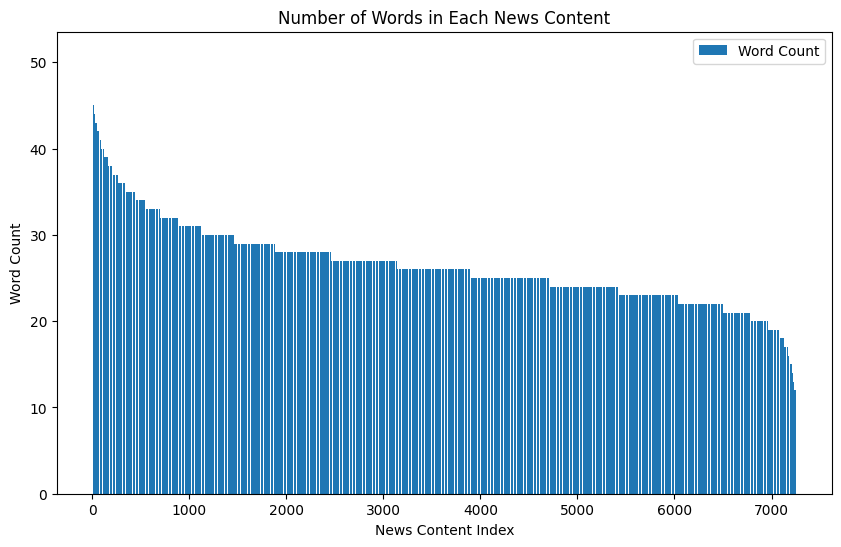

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Calculate word count
df['word_count'] = df['content'].apply(lambda x: len(x.split()))

# Calculate averages
average_word_count = df['word_count'].mean()

# Display results
print(f"Average Word Count: {average_word_count}")


# Plot word counts
plt.figure(figsize=(10, 6))
plt.bar(df.index, df['word_count'].sort_values(ascending=False), label='Word Count')
plt.title('Number of Words in Each News Content')
plt.xlabel('News Content Index')
plt.ylabel('Word Count')
plt.legend()
plt.show()

### Get relevant news by embedding

In [3]:
from openai import OpenAI
from typing import List
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def embed_with_openai(text: str)-> list[float]:
    """
    Embed text using the OpenAI API.

    Args:
        texts (str): Text inputs to be embedded.

    Returns:
        list[float]: List of embeddings for the input texts.
    """    
    client = OpenAI()
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )

    return response.data[0].embedding



def get_relevant_news(question_embedding: List[float], news_df: pd.DataFrame) -> pd.DataFrame:
    """
    Finds and returns relevant news items from the dataframe based on cosine similarity with the question embedding.

    Args:
    - question_embedding (List[float]): The embedding vector for the question, as a list of floats.
    - news_df (pd.DataFrame): The DataFrame containing news articles and their embeddings.

    Returns:
    - pd.DataFrame: A DataFrame of relevant news articles sorted by cosine similarity.
    """
    question_embedding = np.array(question_embedding)
    news_embeddings = np.array(list(news_df['openai_embedding']))
    
    # Calculate cosine similarity between the question and each news embedding
    similarities = cosine_similarity([question_embedding], news_embeddings)[0]
    
    # Add similarity scores to the DataFrame
    news_df = news_df.copy()
    news_df['similarity'] = similarities
    
    # Filter news with cosine similarity greater than 0.41
    relevant_news = news_df[news_df['similarity'] > 0.41]
    
    # Sort by similarity in descending order
    relevant_news = relevant_news.sort_values(by='similarity', ascending=False)
    
    return relevant_news[['content', 'similarity']]

# Building the models functions

## BERT: DistilBERT

In [15]:
from transformers import DistilBertTokenizer, DistilBertForQuestionAnswering, pipeline
import torch
import pandas as pd
from typing import List

# Load the DistilBERT model and tokenizer for question-answering
model_name = "distilbert-base-uncased-distilled-squad"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForQuestionAnswering.from_pretrained(model_name)

def answer_question_with_distilbert(
    question_text: str, 
    model, 
    relevant_news: pd.DataFrame,
    tokenizer
) -> str:
    """
    Generates an answer to the question based only on the relevant news articles provided.

    Args:
    - question_text (str): The text of the question to be answered.
    - model: The loaded DistilBERT model for question-answering.
    - relevant_news (pd.DataFrame): DataFrame containing relevant news articles and their similarity scores.

    Returns:
    - str: The model-generated answer to the question.
    """
    # Combine relevant news content into a single context passage
    context = ". ".join(relevant_news['content'].tolist())
    
    # Limit context to a reasonable length for BERT input (DistilBERT context size limit is 512 tokens)
    if len(context) > 450:
        # print(f"Warning: DistilBERT context length {len(context)} exceeds 450 tokens. Truncating to 450 tokens.")
        context = context[:450]
    
    # Tokenize input for model with separate question and context
    inputs = tokenizer(question_text, context, return_tensors="pt", truncation=True, max_length=512)
    
    # Generate the answer
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Extract the answer text from model outputs
    start_index = torch.argmax(outputs.start_logits)
    end_index = torch.argmax(outputs.end_logits) + 1
    answer = tokenizer.decode(inputs['input_ids'][0][start_index:end_index], skip_special_tokens=True)
    
    return answer

In [17]:

question_dict = questions_answers[6]
question_emb = embed_with_openai(question_dict['question'])
relevant_news_df = get_relevant_news(question_emb, df)
question_dict['distilbert_answer'] = answer_question_with_distilbert(question_dict['question'], model, relevant_news_df, tokenizer)

for key, value in question_dict.items():
    print(f"{key}: {value}")

question: What new policies, if any, have been introduced in England regarding cancer testing?
chatgpt-4o_answer: There is no specific mention of new policies, only that almost three million people were tested.
distilbert_answer: test for patients in england checks if tumours can be treated with pills rather than chemotherapy


## BART (seq2seq)

In [18]:
from transformers import BartTokenizer, BartForConditionalGeneration
import pandas as pd

# Load the BART model and tokenizer for sequence-to-sequence generation
model_name = "facebook/bart-large-cnn"
tokenizer = BartTokenizer.from_pretrained(model_name)
model = BartForConditionalGeneration.from_pretrained(model_name)

def answer_question_with_bart(
    question_text: str, 
    model, 
    relevant_news: pd.DataFrame,
    tokenizer
) -> str:
    """
    Generates an answer to the question based only on the relevant news articles provided.

    Args:
    - question_text (str): The text of the question to be answered.
    - model: The loaded BART model for sequence-to-sequence generation.
    - relevant_news (pd.DataFrame): DataFrame containing relevant news articles.

    Returns:
    - str: The model-generated answer to the question.
    """
    # Combine relevant news content into a single context passage
    context = ". ".join(relevant_news['content'].tolist())
    
    # Limit context to a reasonable length for BART input (BART's max is 1024 tokens)
    if len(context) > 1024:
        # print(f"Warning: Context length ({len(context)}) exceeds BART's maximum limit. Truncating to 1024 tokens.")
        context = context[:1024]
    
    # Prompt that distinguishes the question from the context
    prompt = f"Context: {context} Question: {question_text} Answer based only on the context above."
    
    # Encode the input text
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
    
    # Generate the answer
    summary_ids = model.generate(inputs['input_ids'], num_beams=4, max_length=100, early_stopping=True)
    answer = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    
    return answer

In [20]:
question_dict = questions_answers[6]
question_emb = embed_with_openai(question_dict['question'])
relevant_news_df = get_relevant_news(question_emb, df)
question_dict['bart_answer'] = answer_question_with_bart(question_dict['question'], model, relevant_news_df, tokenizer)

for key, value in question_dict.items():
    print(f"{key}: {value}")

question: What new policies, if any, have been introduced in England regarding cancer testing?
chatgpt-4o_answer: There is no specific mention of new policies, only that almost three million people were tested.
distilbert_answer: test for patients in england checks if tumours can be treated with pills rather than chemotherapy
bart_answer: Cancer waiting times in 2023 worst on record in England. Proportion starting treatment within 62 days in England drops to new low after 11 years of decline. Thousands of cancer patients to trial personalised vaccines. BRCA tests to be offered to Jewish people to detect cancer risk. NHS England says it wants to test 30,000 Jewish people over the next two years.


## FLAN-T5

In [21]:
from transformers import T5Tokenizer, T5ForConditionalGeneration
import pandas as pd

# Load the FLAN-T5 model and tokenizer (using a smaller model variant like FLAN-T5-Large)
model_name = "google/flan-t5-large"  # Switch to "flan-t5-large" or even "flan-t5-base" for faster speed
tokenizer = T5Tokenizer.from_pretrained(model_name)
model = T5ForConditionalGeneration.from_pretrained(model_name)

# # Set device to MPS if available on Mac, otherwise use CPU
# device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
# print(f"Using device: {device}")
# model = model.to(device)

def answer_question_with_flan_t5(
    question_text: str, 
    model, 
    relevant_news: pd.DataFrame,
    tokenizer
) -> str:
    """
    Generates an answer to the question based only on the relevant news articles provided.

    Args:
    - question_text (str): The text of the question to be answered.
    - model: The loaded FLAN-T5 model for sequence-to-sequence generation.
    - relevant_news (pd.DataFrame): DataFrame containing relevant news articles.

    Returns:
    - str: The model-generated answer to the question.
    """
    # Combine relevant news content into a single context passage
    context = ". ".join(relevant_news['content'].tolist())
    
    # Limit context to a reasonable length for FLAN-T5-Large (smaller models may handle fewer tokens)
    if len(context) > 1000:  # Reduce token length for smaller models if needed
        # print(f"Warning: Context length ({len(context)}) exceeds limit. Truncating to 1000 tokens.")
        context = context[:1000]
    
    # Prepare the prompt with clear instruction for FLAN-T5
    prompt = f"Answer the question based ONLY on the news provided: {context} Question: {question_text}"
    
    # Encode the input and move to device
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
    
    # Generate the answer
    answer_ids = model.generate(inputs['input_ids'], max_length=50, num_beams=2, early_stopping=True)
    answer = tokenizer.decode(answer_ids[0], skip_special_tokens=True)
    
    return answer

In [23]:
question_dict = questions_answers[8]
question_emb = embed_with_openai(question_dict['question'])
relevant_news_df = get_relevant_news(question_emb, df)
question_dict['flan_t5_answer'] = answer_question_with_flan_t5(question_dict['question'], model, relevant_news_df, tokenizer)

for key, value in question_dict.items():
    print(f"{key}: {value}")

question: What are the key arguments behind Israel’s Supreme Court ruling on judicial reform?
chatgpt-4o_answer: The key argument from Israel's Supreme Court was against the judicial reform legislation.
flan_t5_answer: The demands, if implemented, would drastically change the nature of Israel's Gaza campaign


## LLaMA 2 7B (Half-Precision (FP16))
Using the LLaMA with half precision (FP16) for faster inference and lower memory usage, Because it's taking to much time ob my PC.

In [24]:
def answer_question_with_llama(
    question_text: str, 
    pipe: pipeline, 
    relevant_news: pd.DataFrame
) -> str:
    """
    Generates an answer to the question based only on the relevant news articles provided.

    Args:
    - question_text (str): The text of the question to be answered.
    - pipe: The loaded pipeline for question answering.
    - relevant_news (pd.DataFrame): DataFrame containing relevant news articles.

    Returns:
    - str: The model-generated answer to the question.
    """
    # Combine relevant news content into a single context passage
    context = ". ".join(relevant_news['content'].tolist())
    
    # Limit context to a reasonable length for the model (LLaMA has variable limits based on model size)
    if len(context) > 5000: 
        # print(f"Warning: Context length ({len(context)}) exceeds LLaMA's maximum limit. Truncating to 1000 tokens.")
        context = context[:5000]
    
    # prompt = f"Context: {context}\n\nQuestion: {question_text}\nAnswer this question shortly and accurate based ONLY on the context provided:"
    prompt = f"""Below is a passage of text. Use this passage to answer the question that follows. Base your answer only on the information provided in the passage."
    Passage:{context}
    Question: {question_text}
    Answer: Let me answer based only on the given passage."""
#     prompt = f"""[INST] You are a precise question-answering system. Your task is to answer questions based only on the provided context. Do not use any external knowledge.

# Context:
# {context}

# Question: {question_text}

# Requirements:
# 1. Use only information from the context above
# 2. If the answer isn't in the context, say so
# 3. Be concise and direct
# 4. Don't make assumptions or add external information

# Answer: [/INST]"""

    response = pipe(
                prompt,
                return_full_text=False,  # Only get the generated answer
            )
    
    return response[0]['generated_text'].strip()    


import torch
from transformers import pipeline
from huggingface_hub import login
login("<API KEY>")

question_dict = questions_answers[7]
question_emb = embed_with_openai(question_dict['question'])
relevant_news_df = get_relevant_news(question_emb, df)

pipe = pipeline(
        "text-generation", 
        model="meta-llama/Llama-3.2-1B", 
        torch_dtype=torch.bfloat16, 
        device_map="auto",
        max_new_tokens=50,      # Maximum length of answer
        min_new_tokens=10,       # Minimum length of answer
        do_sample=True,          # Enable sampling
        temperature=0.2,         # Moderate temperature for balanced responses
        top_p=0.9,              # Nucleus sampling
        no_repeat_ngram_size=3,  # Avoid repetition
        pad_token_id=None,       # Auto-detect padding token
    )

question_dict['llama_32_1b_answer'] = answer_question_with_llama(question_dict['question'], pipe, relevant_news_df)

question_dict['llama_32_1b_answer']

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /Users/who/.cache/huggingface/token
Login successful


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


"Primrose hill stabbing:Harry Pitman was stabbed on New Years Eve in London'sPrimrose hill. Harry was a 15 year old boy who was stabbed in the neck and chest. He was rushed to hospital but died on the way. The"

In [25]:
# # Clean the model from the MPS
# import gc
# import torch

# # Move the model back to CPU
# model.to("cpu")

# # Delete the model and clear memory
# del model
# gc.collect()

# # For MPS, also empty the cache
# if torch.backends.mps.is_available():
#     torch.mps.empty_cache()


## OpenAI: GPT-4o-mini

In [66]:
import pandas as pd
from openai import OpenAI

# Initialize the OpenAI client
client = OpenAI()  # Replace with your actual OpenAI API key

def answer_question_with_openai(
    question_text: str, 
    relevant_news: pd.DataFrame,
    model: str = "gpt-4o-mini"
) -> str:
    """
    Generates an answer to the question using OpenAI's GPT-4 model, basing it only on the relevant news articles.

    Args:
    - question_text (str): The text of the question to be answered.
    - relevant_news (pd.DataFrame): DataFrame containing relevant news articles.
    - model (str): The model to use, defaulting to "gpt-4o-mini".

    Returns:
    - str: The model-generated answer to the question.
    """
    # Combine relevant news content into a single context passage
    context = "<p>"
    context += "</p><p>".join(relevant_news['content'].tolist())
    context += "</p>"
    
    # Limit context length if necessary (for efficient processing)
    max_context_length = 5000  # Character limit to control token usage
    if len(context) > max_context_length:
        context = context[:max_context_length]
    
    # Format the prompt as specified
    user_message_content = f"""Context: {context}
        Question: {question_text}
        Answer accurately and concisely based only on the provided context, focusing on the most relevant details:"""
        
    # Call the OpenAI API with the specified prompt
    completion = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {"role": "user", "content": user_message_content}
        ]
    )
    
    # Extract the answer from the response
    answer = completion.choices[0].message.content.strip()
    
    return answer

In [67]:
question_dict = questions_answers[5]
question_emb = embed_with_openai(question_dict['question'])
relevant_news_df = get_relevant_news(question_emb, df)
question_dict['gpt-4o-mini_answer'] = answer_question_with_openai(question_dict['question'], relevant_news_df)

for key, value in question_dict.items():
    print(f"{key}: {value}")

question: What are the implications of the energy price rise on households?
chatgpt-4o_answer: The energy price rise will likely increase household expenses by 5%.
gpt-4o-mini_answer: The recent energy price rise of 5% results in an increase of £94 to the typical annual domestic energy bill due to a higher energy price cap that will take effect. Households will be facing higher costs for gas and electricity, necessitating that energy firms provide more support to customers who are struggling financially. However, there is some positive news as annual energy bills are forecast to drop significantly in April, with predictions suggesting a reduction of £300, which would improve the financial burden on households coinciding with the arrival of better weather. Overall, while immediate costs are rising, there are projections of future decreases in energy bills which could alleviate some of the pressures on households later in the year.
question_emb: [-0.00042447427404113114, -0.0105290059000

## Loop all the models

In [28]:
import time
from transformers import DistilBertTokenizer, DistilBertForQuestionAnswering, BartTokenizer, BartForConditionalGeneration, T5Tokenizer, T5ForConditionalGeneration, pipeline
from openai import OpenAI
import torch
from huggingface_hub import login

# # OpenAI client setup for gpt-4o-mini
client = OpenAI(api_key="<API KEY>")  # Replace with your OpenAI API key

# Hugging Face login for Hugging Face Hub
login("<API KEY>")

# Function to answer questions based on the model name
def answer_question_with_model(model_name, question, relevant_news_df):
    if model_name == "distilbert":
        tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased-distilled-squad")
        model = DistilBertForQuestionAnswering.from_pretrained("distilbert-base-uncased-distilled-squad")
        return answer_question_with_distilbert(question, model, relevant_news_df, tokenizer)
    
    elif model_name == "bart":
        tokenizer = BartTokenizer.from_pretrained("facebook/bart-large-cnn")
        model = BartForConditionalGeneration.from_pretrained("facebook/bart-large-cnn")
        return answer_question_with_bart(question, model, relevant_news_df, tokenizer)
    
    elif model_name == "flan_t5":
        tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-large")
        model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-large")
        return answer_question_with_flan_t5(question, model, relevant_news_df, tokenizer)
    
    elif model_name == "llama_32_1b":
        pipe = pipeline(
            "text-generation", 
            model="meta-llama/Llama-3.2-1B", 
            torch_dtype=torch.bfloat16, 
            device_map="auto",
            max_new_tokens=50,      # Maximum length of answer
            min_new_tokens=10,       # Minimum length of answer
            do_sample=True,          # Enable sampling
            temperature=0.2,         # Moderate temperature for balanced responses
            top_p=0.9,              # Nucleus sampling
            no_repeat_ngram_size=3,  # Avoid repetition
            pad_token_id=None,       # Auto-detect padding token
        )
        return answer_question_with_llama(question, pipe, relevant_news_df)

    
    elif model_name == "gpt_4o_mini":
        return answer_question_with_openai(question, relevant_news_df)

# Models list and questions/answers dictionary
models_list = ['distilbert', 'bart', 'flan_t5', 'gpt_4o_mini', 'llama_32_1b']


# Loop through each model and answer each question
for model_name in models_list:
    for i, question_dict in enumerate(questions_answers):
        if 'question_emb' not in question_dict:
            question_dict['question_emb'] = embed_with_openai(question_dict['question'])
        
        question_emb = question_dict['question_emb']
        relevant_news_df = get_relevant_news(question_emb, df)
        if len(relevant_news_df) == 0:
            print(f"No relevant news found for question {i}. Skipping...")
            continue    
        start_time = time.time()

        # Get the answer from the model
        answer = answer_question_with_model(model_name, question_dict['question'], relevant_news_df)
        
        # Calculate time taken and print
        elapsed_time = time.time() - start_time
        print(f"Model {model_name} took {elapsed_time:.2f} seconds to answer the ({i+1}) question.")
        
        # Store the answer in the question dictionary
        question_dict[f"{model_name}_answer"] = answer

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /Users/who/.cache/huggingface/token
Login successful
Model distilbert took 0.92 seconds to answer the (1) question.
Model distilbert took 0.60 seconds to answer the (2) question.
Model distilbert took 0.61 seconds to answer the (3) question.
Model distilbert took 0.65 seconds to answer the (4) question.
Model distilbert took 0.61 seconds to answer the (5) question.
Model distilbert took 0.60 seconds to answer the (6) question.
Model distilbert took 0.58 seconds to answer the (7) question.
Model distilbert took 0.71 seconds to answer the (8) question.
Model distilbert took 0.59 seconds to answer the (9) question.
Model distilbert took 0.60 seconds to answer the (10) question.
Model distilbert t

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Model llama_32_1b took 6.79 seconds to answer the (1) question.


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Model llama_32_1b took 6.30 seconds to answer the (2) question.


...

Model llama_32_1b took 7.47 seconds to answer the (18) question.


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Model llama_32_1b took 7.53 seconds to answer the (19) question.


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Model llama_32_1b took 7.52 seconds to answer the (20) question.


In [69]:
questions_answers_df = pd.DataFrame(questions_answers)

In [70]:
questions_answers_df[['question','chatgpt-4o_answer', 'distilbert_answer', 'bart_answer', 'flan_t5_answer', 'llama_32_1b_answer', 'gpt_4o_mini_answer']]

,question,chatgpt-4o_answer,distilbert_answer,bart_answer,flan_t5_answer,llama_32_1b_answer,gpt_4o_mini_answer
0,Who commented on how political leaders should ...,Justin Welby advised political leaders to trea...,justin welby,Justin Welby: Political leaders should treat o...,Justin Welby,The passage says that political leaders need t...,"Justin Welby, the Archbishop of Canterbury, co..."
1,How many people were tested for cancer in Engl...,Nearly three million people were tested for ca...,almost three million,Treatment targets are still being missed in En...,Almost three million,The passage says that almost three million peo...,Almost three million people were tested for ca...
2,By what percentage have household energy price...,Household energy prices increased by 5%.,5 %,Household energy price rise of 5% comes into f...,5%,"The answer is 5%. The energy cap is 6%. So, th...",Household energy prices have increased by 5%.
3,Who was identified in connection with a stabbi...,Harry Pitman was named in connection with the ...,harry pitman,"Harry Pitman, 16, stabbed to death on New Year...",Boy,The answer is Harry Pitmann. Harry was identif...,"Harry Pitman, a 16-year-old, was identified as..."
4,What recent decision did Israel's Supreme Cour...,Israel's Supreme Court struck down judicial re...,strikes down,Israel Supreme Court strikes down judicial ref...,strikes down,The Supreme Court of Israel struck down the ju...,Israel's Supreme Court struck down judicial re...
5,What are the implications of the energy price ...,The energy price rise will likely increase hou...,5 %,Household energy price rise of 5% comes into f...,A higher cap for the next three months adds £9...,The new energy prices cap will be effective fr...,The energy price rise of 5% and the increased ...
6,"What new policies, if any, have been introduce...","There is no specific mention of new policies, ...",test for patients in england checks if tumours...,Cancer waiting times in 2023 worst on record i...,Thousands of cancer patients to trial personal...,The passage says that the number for cancer te...,Recent policies in England regarding cancer te...
7,In which city did the Primrose Hill stabbing t...,"The stabbing occurred in Primrose Hill, London...",north london,"Harry Pitman, 16, was attacked on London's Pri...",London,Primrose hill stabbing:Harry Pitman was stabbe...,The Primrose Hill stabbing took place in Londo...
8,What are the key arguments behind Israel’s Sup...,The key argument from Israel's Supreme Court w...,the controversial plans triggered nationwide p...,Israel Supreme Court strikes down judicial ref...,"The demands, if implemented, would drastically...",The key arguments are that the reforms would h...,The provided context does not explicitly outli...
9,How have political leaders been advised to app...,Political leaders have been advised by Justin ...,human beings,Justin Welby: Political leaders should treat o...,as human beings,The passage says that political leaders should...,Political leaders have been advised to treat t...


In [71]:
questions_answers_df[['question','chatgpt-4o_answer', 'distilbert_answer', 'bart_answer', 'flan_t5_answer', 'llama_32_1b_answer', 'gpt_4o_mini_answer']].to_csv('models_question_answers.csv', index=False)

# Evaluate the models

Step-by-Step Code for Evaluation with Cosine Similarity
1. Load the CSV file and reference answers.
2. Compute embeddings for each answer and the reference answer.
3. Calculate cosine similarity between each model’s answer and the reference.
4. Identify the model with the highest similarity score for each question.

In [72]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from typing import Dict
import numpy as np

# Load the CSV file with all model answers
models_answer_df = pd.read_csv("models_question_answers.csv")

# Load the e5-large-v2 model and tokenizer
model_name = "intfloat/e5-large-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(text: str) -> np.ndarray:
    """
    Generates the embedding for a given text using the e5-large-v2 model.

    Args:
    - text (str): The text to be embedded.

    Returns:
    - np.ndarray: A 1D array representing the sentence embedding of the input text.
    """
    # Ensure the input is a string to avoid errors
    text = str(text)
    
    # Tokenize and generate embeddings
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        embeddings = model(**inputs).last_hidden_state[:, 0, :]  # Use CLS token embedding
    return embeddings.squeeze().numpy()

def evaluate_answers(row: pd.Series) -> pd.Series:
    """
    Evaluates the similarity of each model's answer to the reference answer for a given question.

    Args:
    - row (pd.Series): A row from the DataFrame containing the question, reference answer, 
      and answers from each model.

    Returns:
    - pd.Series: The row with additional columns for each model's similarity score and the best model.
    """
    # Ensure all answers are strings, replace non-string types with an empty string if necessary
    reference_answer = str(row.get('chatgpt-4o_answer', ""))
    distilbert_answer = str(row.get('distilbert_answer', ""))
    bart_answer = str(row.get('bart_answer', ""))
    flan_t5_answer = str(row.get('flan_t5_answer', ""))
    llama_32_1b_answer = str(row.get('llama_32_1b_answer', ""))
    gpt_4o_mini_answer = str(row.get('gpt_4o_mini_answer', ""))

    # Compute embeddings for the reference and each model's answer
    reference_embedding = get_embedding(reference_answer)
    distilbert_embedding = get_embedding(distilbert_answer)
    bart_embedding = get_embedding(bart_answer)
    flan_t5_embedding = get_embedding(flan_t5_answer)
    llama_32_1b_embedding = get_embedding(llama_32_1b_answer)
    gpt_4o_mini_embedding = get_embedding(gpt_4o_mini_answer)

    # Calculate cosine similarities with the reference answer
    scores: Dict[str, float] = {
        'distilbert': cosine_similarity([reference_embedding], [distilbert_embedding])[0][0],
        'bart': cosine_similarity([reference_embedding], [bart_embedding])[0][0],
        'flan_t5': cosine_similarity([reference_embedding], [flan_t5_embedding])[0][0],
        'llama_32_1b': cosine_similarity([reference_embedding], [llama_32_1b_embedding])[0][0],
        'gpt_4o_mini': cosine_similarity([reference_embedding], [gpt_4o_mini_embedding])[0][0]
    }

    # Determine the model with the highest score
    best_model: str = max(scores, key=scores.get)
    row['best_model'] = best_model
    row['best_model_score'] = scores[best_model]
    
    # Optionally, add each model's score for review
    for model, score in scores.items():
        row[f"{model}_score"] = score

    return row

# Apply the evaluation function to each row in the DataFrame
models_answer_df = models_answer_df.apply(evaluate_answers, axis=1)

# Save the updated DataFrame with evaluation scores
models_answer_df.to_csv("models_evaluation.csv", index=False)

# Display the first few rows of the evaluated data
models_answer_df.head()

,question,chatgpt-4o_answer,distilbert_answer,bart_answer,flan_t5_answer,llama_32_1b_answer,gpt_4o_mini_answer,best_model,best_model_score,distilbert_score,bart_score,flan_t5_score,llama_32_1b_score,gpt_4o_mini_score
0,Who commented on how political leaders should ...,Justin Welby advised political leaders to trea...,justin welby,Justin Welby: Political leaders should treat o...,Justin Welby,The passage says that political leaders need t...,"Justin Welby, the Archbishop of Canterbury, co...",distilbert,0.833558,0.833558,0.793464,0.833558,0.756486,0.816313
1,How many people were tested for cancer in Engl...,Nearly three million people were tested for ca...,almost three million,Treatment targets are still being missed in En...,Almost three million,The passage says that almost three million peo...,Almost three million people were tested for ca...,gpt_4o_mini,0.976812,0.770255,0.765310,0.770255,0.913825,0.976812
2,By what percentage have household energy price...,Household energy prices increased by 5%.,5 %,Household energy price rise of 5% comes into f...,5%,"The answer is 5%. The energy cap is 6%. So, th...",Household energy prices have increased by 5%.,gpt_4o_mini,0.991280,0.802470,0.842999,0.802470,0.840392,0.991280
3,Who was identified in connection with a stabbi...,Harry Pitman was named in connection with the ...,harry pitman,"Harry Pitman, 16, stabbed to death on New Year...",Boy,The answer is Harry Pitmann. Harry was identif...,"Harry Pitman, a 16-year-old, was identified as...",gpt_4o_mini,0.934772,0.832420,0.845370,0.686844,0.863816,0.934772
4,What recent decision did Israel's Supreme Cour...,Israel's Supreme Court struck down judicial re...,strikes down,Israel Supreme Court strikes down judicial ref...,strikes down,The Supreme Court of Israel struck down the ju...,Israel's Supreme Court struck down judicial re...,gpt_4o_mini,0.915587,0.721156,0.840241,0.721156,0.869071,0.915587


In [73]:
for index, row in models_answer_df.iterrows():
    best_model_name = row['best_model']
    print(f"{index+1})\tQuestion:\t{row['question']}\n\tChatGPT answer: {row['chatgpt-4o_answer']}\n\tBest answer:\t{row[best_model_name+'_answer']}\n\tModel: \033[96m\033[4m{row['best_model']}\033[0m\t Score: {row['best_model_score']:.3f}\n{'-'*100}")

1)	Question:	Who commented on how political leaders should treat others, and what was the context?
	ChatGPT answer: Justin Welby advised political leaders to treat others with respect and compassion.
	Best answer:	justin welby
	Model: distilbert	 Score: 0.834
----------------------------------------------------------------------------------------------------
2)	Question:	How many people were tested for cancer in England recently?
	ChatGPT answer: Nearly three million people were tested for cancer in England.
	Best answer:	Almost three million people were tested for cancer in England recently.
	Model: gpt_4o_mini	 Score: 0.977
----------------------------------------------------------------------------------------------------
3)	Question:	By what percentage have household energy prices increased?
	ChatGPT answer: Household energy prices increased by 5%.
	Best answer:	Household energy prices have increased by 5%.
	Model: gpt_4o_mini	 Score: 0.991
-----------------------------------------